# Temporal Fusion Transformer (TFT) — PM2.5 Forecasting
This notebook trains a TFT model on station data and evaluates it with multiple metrics:
**RMSE, MSE, R², and F1-Score** (via a PM2.5 threshold classification).

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import torch
import lightning.pytorch as pl
from lightning.pytorch.trainer import Trainer
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss
from pytorch_forecasting.data.encoders import GroupNormalizer
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from lightning.pytorch.loggers import CSVLogger
import matplotlib.pyplot as plt
import os, sys
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
print(sys.executable)
print(torch.__file__)
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
%matplotlib inline

c:\Users\ssupa\Code\Pm2.5_forcast\model\TFT\venv_tft\Lib\site-packages\pytorch_forecasting\models\base\_base_model.py:30: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


c:\Users\ssupa\Code\Pm2.5_forcast\model\TFT\venv_tft\Scripts\python.exe
c:\Users\ssupa\Code\Pm2.5_forcast\model\TFT\venv_tft\Lib\site-packages\torch\__init__.py
2.5.1+cu121
12.1
True


## 2. Load & Prepare Data

In [2]:
df = pd.read_csv("44T_cleaned_features.csv")

df = df.rename(columns={
    "Wind Speed": "Wind_Speed",
    "Temp.": "Temp",
    "Humi.": "Humi",
    "Pres.": "Pres",
    "Prec.": "Prec",
    "Vis.": "Vis",
    "PM2.5": "PM25",
    "PM2.5_lag1": "PM25_lag1",
    "PM2.5_lag2": "PM25_lag2",
    "PM2.5_lag3": "PM25_lag3",
    "PM2.5_lag7": "PM25_lag7",
    "PM2.5_lag14": "PM25_lag14",
    "PM2.5_lag30": "PM25_lag30",
    "PM2.5_rollmean3": "PM25_rollmean3",
    "PM2.5_rollstd3": "PM25_rollstd3",
    "PM2.5_rollmean7": "PM25_rollmean7",
    "PM2.5_rollstd7": "PM25_rollstd7",
    "PM2.5_rollmean14": "PM25_rollmean14",
    "PM2.5_rollstd14": "PM25_rollstd14",
    "Wind Dir_sin": "Wind_Dir_sin",
    "Wind Dir_cos": "Wind_Dir_cos",
    "Prec._lag1": "Prec_lag1",
    "Prec._lag2": "Prec_lag2",
    "Prec._lag3": "Prec_lag3",
    "Prec._lag7": "Prec_lag7",
    "Prec._lag14": "Prec_lag14",
    "Prec._rollsum3": "Prec_rollsum3",
    "Prec._rollmean3": "Prec_rollmean3",
    "Prec._rollsum7": "Prec_rollsum7",
    "Prec._rollmean7": "Prec_rollmean7",
    "Prec._rollsum14": "Prec_rollsum14",
    "Prec._rollmean14": "Prec_rollmean14",
})

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"Rows before dropna: {len(df)}")
df = df.dropna(
    subset=[c for c in df.columns if c != "Vis"]
).reset_index(drop=True)
print(f"Rows after dropna:  {len(df)}")

df.head()

Rows before dropna: 1268
Rows after dropna:  1238


,Date,Wind_Speed,Temp,Humi,heatidx,Pres,Prec,Vis,PM25,year,...,Prec_lag2,Prec_lag3,Prec_lag7,Prec_lag14,Prec_rollsum3,Prec_rollmean3,Prec_rollsum7,Prec_rollmean7,Prec_rollsum14,Prec_rollmean14
0,2013-03-25,2.3,29.1,65.0,31.9,1005.3,0.0,NaN,23.0,2013,...,0.0,0.0,8.0,1.0,0.0,0.0,23.4,3.342857,54.6,3.900000
1,2013-03-26,2.2,29.7,65.5,33.4,1005.7,0.0,NaN,25.0,2013,...,0.0,0.0,15.4,0.0,0.0,0.0,15.4,2.200000,53.6,3.828571
2,2013-03-28,2.4,29.2,70.2,33.3,1006.5,0.0,NaN,25.0,2013,...,0.0,0.0,0.0,0.6,0.0,0.0,0.0,0.000000,53.6,3.828571
3,2013-03-29,2.4,29.3,71.3,33.7,1005.9,0.0,NaN,22.0,2013,...,0.0,0.0,0.0,15.6,0.0,0.0,0.0,0.000000,53.0,3.785714
4,2013-04-02,3.1,29.6,71.9,34.6,1006.3,0.0,NaN,10.0,2013,...,0.0,0.0,0.0,14.0,0.0,0.0,0.0,0.000000,37.4,2.671429


## 3. Feature Engineering

In [3]:
# Calendar features
df['month'] = df['Date'].dt.month
df['day_of_week'] = df['Date'].dt.dayofweek.astype(str)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# TFT requirements
df['time_idx'] = np.arange(len(df))
df['group_id'] = "station_05T"

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['Date'].min()} → {df['Date'].max()}")
df.describe()

Dataset shape: (1238, 45)
Date range: 2013-03-25 00:00:00 → 2025-06-30 00:00:00


,Date,Wind_Speed,Temp,Humi,heatidx,Pres,Prec,Vis,PM25,year,...,Prec_lag7,Prec_lag14,Prec_rollsum3,Prec_rollmean3,Prec_rollsum7,Prec_rollmean7,Prec_rollsum14,Prec_rollmean14,month,time_idx
count,1238,1238.000000,1238.000000,1238.000000,1238.000000,1238.000000,1238.000000,0.0,1238.000000,1238.000000,...,1238.000000,1238.000000,1238.000000,1238.000000,1238.000000,1238.000000,1238.000000,1238.000000,1238.000000,1238.000000
mean,2022-05-22 20:09:41.583198720,2.736228,27.541922,82.294709,31.639459,1006.886672,6.903554,NaN,15.802908,2021.901454,...,6.914216,6.903877,20.710662,6.903554,48.347334,6.906762,96.724717,6.908908,6.383683,618.500000
min,2013-03-25 00:00:00,0.000000,-7.800000,0.500000,0.000000,0.000000,0.000000,NaN,5.700000,2013.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,2022-02-09 00:00:00,2.000000,26.700000,77.725000,29.600000,1006.700000,0.000000,NaN,11.400000,2022.000000,...,0.000000,0.000000,0.000000,0.000000,7.200000,1.028571,32.400000,2.314286,4.000000,309.250000
50%,2023-10-15 12:00:00,2.500000,27.700000,82.400000,31.700000,1007.900000,0.000000,NaN,14.800000,2023.000000,...,0.000000,0.000000,6.200000,2.066667,27.200000,3.885714,70.100000,5.007143,6.000000,618.500000
75%,2024-08-19 18:00:00,3.400000,28.800000,87.200000,33.800000,1009.000000,5.000000,NaN,19.000000,2024.000000,...,5.000000,5.000000,25.950000,8.650000,60.200000,8.600000,125.800000,8.985714,9.000000,927.750000
max,2025-06-30 00:00:00,6.300000,33.200000,99.900000,72.300000,1014.100000,179.800000,NaN,53.000000,2025.000000,...,179.800000,179.800000,460.000000,153.333333,646.600000,92.371429,753.400000,53.814286,12.000000,1237.000000
std,NaN,0.998869,2.466715,8.165714,3.927292,29.173297,17.509879,NaN,6.436400,3.585426,...,17.510400,17.509055,37.409489,12.469830,68.040078,9.720011,106.654140,7.618153,3.337006,357.524125


## 4. Define Variable Groups & Create TimeSeriesDataSet

In [4]:
# Known in advance (calendar / time features)
known_reals = ["time_idx", "month_sin", "month_cos"]
known_categoricals = ["day_of_week"]

# Unknown at forecast time (observed weather & lag features)
unknown_reals = [
    "PM25_rollmean14",
    "PM25_rollmean7",
    "PM25_lag1",
    "PM25_rollmean3",
    "Prec",
    "Pres",
    "Humi",
    "Wind_Dir_cos"
]

max_encoder_length = 30   # look-back window
max_prediction_length = 1  # forecast horizon

training_cutoff = int(df["time_idx"].max() * 0.8)
print(f"Training cutoff time_idx: {training_cutoff}  (total: {df['time_idx'].max()})")

# --- Batch Normalize continuous features (fit on train only) ---
cols_to_scale = unknown_reals + ["month_sin", "month_cos"]
scaler = StandardScaler()
train_mask = df["time_idx"] <= training_cutoff
scaler.fit(df.loc[train_mask, cols_to_scale])
df[cols_to_scale] = scaler.transform(df[cols_to_scale])
print(f"Scaled {len(cols_to_scale)} features (fit on training split only)")

training = TimeSeriesDataSet(
    df[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="PM25",
    group_ids=["group_id"],
    min_encoder_length=max_encoder_length,
    max_encoder_length=max_encoder_length,
    min_prediction_length=max_prediction_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=["group_id"],
    time_varying_known_categoricals=known_categoricals,
    time_varying_known_reals=known_reals,
    time_varying_unknown_reals=unknown_reals,
    target_normalizer=GroupNormalizer(
        groups=["group_id"], transformation="softplus"
    ),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

validation = TimeSeriesDataSet.from_dataset(
    training,
    df,
    min_prediction_idx=training_cutoff + 1,
    stop_randomization=True,
)

batch_size = 64
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size * 10, num_workers=0)

print(f"Training samples:   {len(training)}")
print(f"Validation samples: {len(validation)}")

Training cutoff time_idx: 989  (total: 1237)
Scaled 10 features (fit on training split only)
Training samples:   960
Validation samples: 248


## 5. Hyperparameter Grid Search
Search over combinations of `hidden_size`, `dropout`, `learning_rate`, and `attention_head_size`.
Each configuration trains for a small number of epochs; the best is used for full training later.

In [ ]:
from itertools import product

# --- Define the parameter grid ---
param_grid = {
    "hidden_size":        [32, 64, 128],
    "dropout":            [0.1, 0.2, 0.3],
    "learning_rate":      [1e-3, 5e-4],
    "attention_head_size": [2, 4],
}

GRID_SEARCH_EPOCHS = 30  # short runs to compare configurations

keys = list(param_grid.keys())
combos = list(product(*param_grid.values()))
print(f"Total combinations to evaluate: {len(combos)}")

grid_results = []

for i, values in enumerate(combos):
    params = dict(zip(keys, values))
    print(f"\n[{i+1}/{len(combos)}] {params}")

    model = TemporalFusionTransformer.from_dataset(
        training,
        learning_rate=params["learning_rate"],
        hidden_size=params["hidden_size"],
        attention_head_size=params["attention_head_size"],
        dropout=params["dropout"],
        hidden_continuous_size=params["hidden_size"] // 2,
        output_size=7,
        loss=QuantileLoss(),
        optimizer="adamw",
        weight_decay=1e-2,
        reduce_on_plateau_patience=3,
        reduce_on_plateau_reduction=10,
        reduce_on_plateau_min_lr=1e-6,
    )

    gs_logger = CSVLogger("logs", name="44T_Rand1_Features_BN", version=i)

    gs_early_stop = EarlyStopping(
        monitor="val_loss", min_delta=1e-4, patience=5, verbose=False, mode="min"
    )

    gs_trainer = Trainer(
        max_epochs=GRID_SEARCH_EPOCHS,
        accelerator="cuda" if torch.cuda.is_available() else "cpu",
        devices=1,
        gradient_clip_val=0.1,
        logger=gs_logger,
        callbacks=[gs_early_stop],
        enable_progress_bar=False,
        enable_model_summary=False,
    )

    gs_trainer.fit(model, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

    best_val_loss = gs_trainer.callback_metrics.get("val_loss", float("inf"))
    if isinstance(best_val_loss, torch.Tensor):
        best_val_loss = best_val_loss.item()

    grid_results.append({**params, "val_loss": best_val_loss})
    print(f"   val_loss = {best_val_loss:.6f}")

print("\nGrid search complete.")

c:\Users\ssupa\Code\Pm2.5_forcast\model\TFT\venv_tft\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\ssupa\Code\Pm2.5_forcast\model\TFT\venv_tft\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pyp

Total combinations to evaluate: 36

[1/36] {'hidden_size': 32, 'dropout': 0.1, 'learning_rate': 0.001, 'attention_head_size': 2}


c:\Users\ssupa\Code\Pm2.5_forcast\model\TFT\venv_tft\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\ssupa\Code\Pm2.5_forcast\model\TFT\venv_tft\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\ssupa\Code\Pm2.5_forcast\model\TFT\venv_tft\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:317: The number of training batches (15) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
GPU available: True (cuda), used

   val_loss = 2.180233

[2/36] {'hidden_size': 32, 'dropout': 0.1, 'learning_rate': 0.001, 'attention_head_size': 4}


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

   val_loss = 2.285225

[34/36] {'hidden_size': 128, 'dropout': 0.3, 'learning_rate': 0.001, 'attention_head_size': 4}


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


   val_loss = 2.010562

[35/36] {'hidden_size': 128, 'dropout': 0.3, 'learning_rate': 0.0005, 'attention_head_size': 2}


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


   val_loss = 1.799767

[36/36] {'hidden_size': 128, 'dropout': 0.3, 'learning_rate': 0.0005, 'attention_head_size': 4}
   val_loss = 1.980303

Grid search complete.


In [6]:
# --- Grid Search Results ---
results_df = pd.DataFrame(grid_results).sort_values("val_loss").reset_index(drop=True)
print("Top 10 configurations:")
display(results_df.head(10))

best_params = results_df.iloc[0].to_dict()
best_val = best_params.pop("val_loss")
# cast back to proper types
best_params["hidden_size"]         = int(best_params["hidden_size"])
best_params["attention_head_size"] = int(best_params["attention_head_size"])

print(f"\nBest val_loss: {best_val:.6f}")
print(f"Best params:   {best_params}")

Top 10 configurations:


,hidden_size,dropout,learning_rate,attention_head_size,val_loss
0,64,0.2,0.0005,2,1.565823
1,128,0.2,0.0005,4,1.606168
2,32,0.2,0.0005,4,1.689722
3,32,0.1,0.0005,4,1.692264
4,64,0.2,0.0010,4,1.698011
5,128,0.1,0.0010,4,1.720660
6,64,0.1,0.0005,4,1.727054
7,32,0.3,0.0010,2,1.752788
8,128,0.1,0.0010,2,1.754148
9,64,0.3,0.0005,2,1.782978



Best val_loss: 1.565823
Best params:   {'hidden_size': 64, 'dropout': 0.2, 'learning_rate': 0.0005, 'attention_head_size': 2}


## 6. Build TFT Model (Best Params from Grid Search)

In [7]:
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=best_params["learning_rate"],
    hidden_size=best_params["hidden_size"],
    attention_head_size=best_params["attention_head_size"],
    dropout=best_params["dropout"],
    hidden_continuous_size=best_params["hidden_size"] // 2,
    output_size=7,             # 7 quantiles
    loss=QuantileLoss(),
    optimizer="adamw",
    weight_decay=1e-2,
    reduce_on_plateau_patience=5,
    reduce_on_plateau_reduction=10,
    reduce_on_plateau_min_lr=1e-6,
)

print(f"Number of parameters in network: {tft.size()/1e3:.1f}k")
print(f"Using: {best_params}")

Number of parameters in network: 353.3k
Using: {'hidden_size': 64, 'dropout': 0.2, 'learning_rate': 0.0005, 'attention_head_size': 2}


c:\Users\ssupa\Code\Pm2.5_forcast\model\TFT\venv_tft\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\ssupa\Code\Pm2.5_forcast\model\TFT\venv_tft\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


## 7. Train the Model (Full Run)

In [ ]:
logger = CSVLogger("logs", name="44T_Rand1_Features_BN")

checkpoint_callback = ModelCheckpoint(
    monitor="val_loss",
    mode="min",
    save_top_k=1,
    filename="best-checkpoint",
)

early_stop_callback = EarlyStopping(
    monitor="val_loss",
    min_delta=1e-4,
    patience=20,
    verbose=True,
    mode="min",
)

trainer = Trainer(
    max_epochs=200,
    accelerator="cuda" if torch.cuda.is_available() else "cpu",
    devices=1,
    gradient_clip_val=0.1,
    logger=logger,
    callbacks=[early_stop_callback,checkpoint_callback],
    enable_progress_bar=True,
)

trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

best_model_path = trainer.checkpoint_callback.best_model_path
print(f"\nBest model saved at: {best_model_path}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embeddings                   | MultiEmbedding                  | 36     | train | 0    
3  | prescalers                         | ModuleDict                      | 1.0 K  | train | 0    
4  | static_variable_selection          | Varia

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\ssupa\Code\Pm2.5_forcast\model\TFT\venv_tft\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


c:\Users\ssupa\Code\Pm2.5_forcast\model\TFT\venv_tft\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\ssupa\Code\Pm2.5_forcast\model\TFT\venv_tft\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:317: The number of training batches (15) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 0: 100%|██████████| 15/15 [00:01<00:00,  8.93it/s, v_num=0, train_loss_step=3.030, val_loss=2.680, train_loss_epoch=3.940]

...

Epoch 9: 100%|██████████| 15/15 [00:01<00:00,  9.04it/s, v_num=0, train_loss_step=2.080, val_loss=1.860, train_loss_epoch=1.940]

Metric val_loss improved by 0.027 >= min_delta = 0.0001. New best score: 1.864


Epoch 29: 100%|██████████| 15/15 [00:01<00:00,  9.13it/s, v_num=0, train_loss_step=1.640, val_loss=1.910, train_loss_epoch=1.780]

Monitored metric val_loss did not improve in the last 20 records. Best score: 1.864. Signaling Trainer to stop.


Epoch 29: 100%|██████████| 15/15 [00:01<00:00,  9.11it/s, v_num=0, train_loss_step=1.640, val_loss=1.910, train_loss_epoch=1.780]

Best model saved at: logs\44T_Rand1_Features\version_0\checkpoints\best-checkpoint.ckpt


## 8. Training & Validation Loss Plot

Loading metrics from: logs\44T_Rand1_Features\version_0/metrics.csv


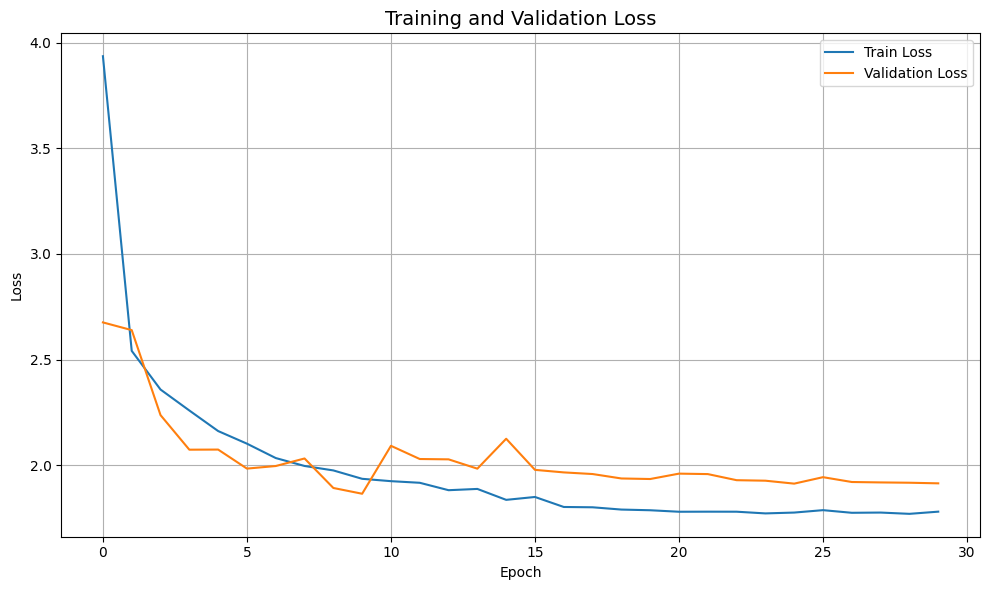

In [9]:
metrics_path = f"{trainer.logger.log_dir}/metrics.csv"
print(f"Loading metrics from: {metrics_path}")
metrics = pd.read_csv(metrics_path)
epoch_metrics = metrics.groupby("epoch").mean()

fig, ax = plt.subplots(figsize=(10, 6))

if 'train_loss_epoch' in epoch_metrics.columns:
    ax.plot(epoch_metrics.index, epoch_metrics['train_loss_epoch'], label='Train Loss')
elif 'train_loss' in epoch_metrics.columns:
    ax.plot(epoch_metrics.index, epoch_metrics['train_loss'], label='Train Loss')

if 'val_loss' in epoch_metrics.columns:
    ax.plot(epoch_metrics.index, epoch_metrics['val_loss'], label='Validation Loss')

ax.set_title('Training and Validation Loss', fontsize=14)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 9. Predictions on Validation Set

In [10]:
# Load best checkpoint
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

# Get actuals and predictions
actuals = torch.cat([y[0] for x, y in iter(val_dataloader)])
predictions = best_tft.predict(val_dataloader)

y_true = actuals.cpu().numpy().flatten()
y_pred = predictions.cpu().numpy().flatten()

print(f"y_true shape: {y_true.shape}")
print(f"y_pred shape: {y_pred.shape}")
print(f"y_true NaNs:  {np.isnan(y_true).any()}")
print(f"y_pred NaNs:  {np.isnan(y_pred).any()}")

c:\Users\ssupa\Code\Pm2.5_forcast\model\TFT\venv_tft\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\ssupa\Code\Pm2.5_forcast\model\TFT\venv_tft\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pyp

y_true shape: (248,)
y_pred shape: (248,)
y_true NaNs:  False
y_pred NaNs:  False


## 10. Regression Metrics — MSE, RMSE, MAE, R²

In [11]:
mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)

print("=" * 45)
print("  Regression Metrics (Validation Set)")
print("=" * 45)
print(f"  MSE  : {mse:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  MAE  : {mae:.4f}")
print(f"  R²   : {r2:.4f}")
print("=" * 45)

  Regression Metrics (Validation Set)
  MSE  : 12.0372
  RMSE : 3.4695
  MAE  : 2.8912
  R²   : 0.5019


## 11. F1-Score (Threshold-based Classification)

PM2.5 > **37.5 µg/m³** is classified as **unhealthy** (Thailand AQI orange level).
We convert predictions & actuals into binary labels and compute the F1-score.

In [ ]:
PM25_THRESHOLD = 37.5  # µg/m³ — adjust as needed

y_true_cls = (y_true > PM25_THRESHOLD).astype(int)
y_pred_cls = (y_pred > PM25_THRESHOLD).astype(int)

f1 = f1_score(y_true_cls, y_pred_cls)

print(f"Threshold: PM2.5 > {PM25_THRESHOLD} µg/m³  →  Unhealthy (1)")
print(f"F1-Score : {f1:.4f}\n")
print(classification_report(y_true_cls, y_pred_cls, target_names=["Normal", "Unhealthy"]))

# Confusion Matrix
cm = confusion_matrix(y_true_cls, y_pred_cls)
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Unhealthy"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues")
ax.set_title("Confusion Matrix (PM2.5 Threshold Classification)")
plt.tight_layout()
plt.show()

## 12. Actual vs Predicted — Scatter Plot

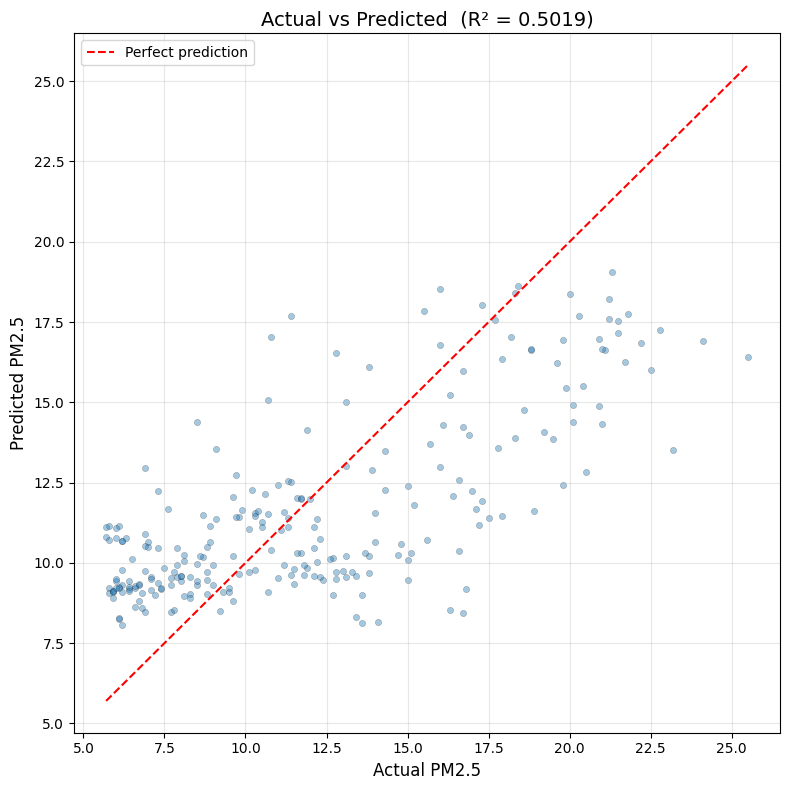

In [13]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_true, y_pred, alpha=0.4, edgecolors='k', linewidths=0.3, s=20)

# Perfect-prediction line
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')

ax.set_xlabel('Actual PM2.5', fontsize=12)
ax.set_ylabel('Predicted PM2.5', fontsize=12)
ax.set_title(f'Actual vs Predicted  (R² = {r2:.4f})', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Actual vs Predicted — Time Series Plot

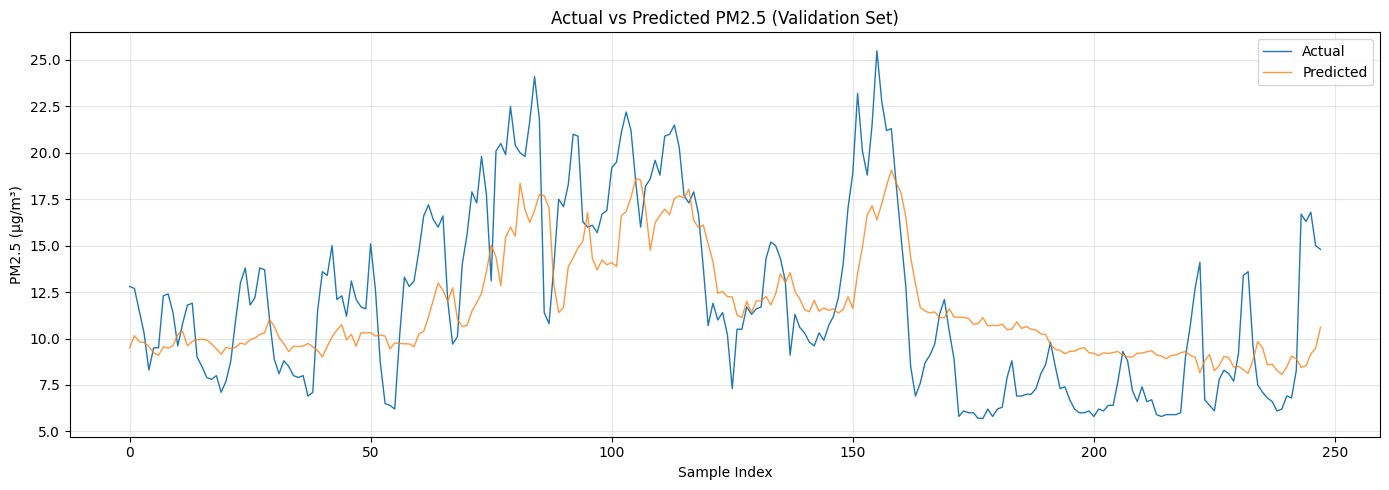

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_true, label='Actual', linewidth=1)
ax.plot(y_pred, label='Predicted', linewidth=1, alpha=0.8)
ax.set_xlabel('Sample Index')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_title('Actual vs Predicted PM2.5 (Validation Set)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 14. Residual Distribution

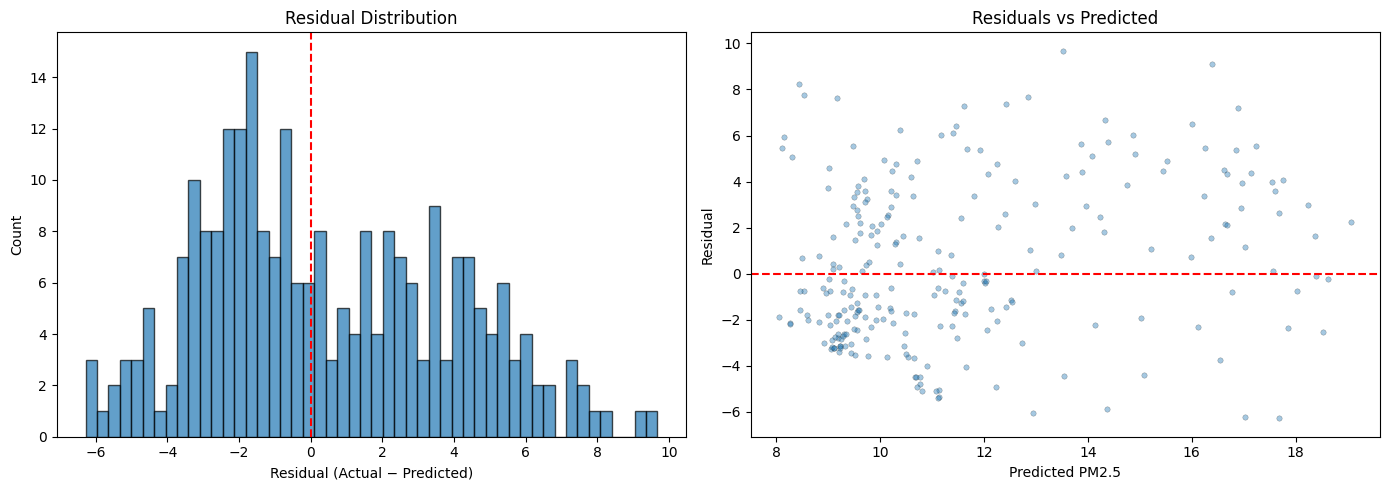

In [15]:
residuals = y_true - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(residuals, bins=50, edgecolor='k', alpha=0.7)
axes[0].axvline(0, color='r', linestyle='--')
axes[0].set_title('Residual Distribution')
axes[0].set_xlabel('Residual (Actual − Predicted)')
axes[0].set_ylabel('Count')

# Residual vs Predicted
axes[1].scatter(y_pred, residuals, alpha=0.4, s=15, edgecolors='k', linewidths=0.3)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted PM2.5')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

## 15. Summary Table

In [16]:
summary = pd.DataFrame({
    "Metric": ["MSE", "RMSE", "MAE", "R²"],
    "Value":  [f"{mse:.4f}", f"{rmse:.4f}", f"{mae:.4f}", f"{r2:.4f}"],
})
summary.style.hide(axis="index")

Metric,Value
MSE,12.0372
RMSE,3.4695
MAE,2.8912
R²,0.5019
